In [130]:
import sys
import os 
import pandas as pd
import numpy as np
import torch 
import seaborn as sns
import matplotlib.pyplot as plt

# load all functions from differential_splicing 
from differential_splicing import *
from estimate_bayesian_fdr import *

In [131]:
# Function for the logit transform
def logit(p):
    return torch.log(p / (1 - p))

# Function for the inverse logit transform (sigmoid)
def inverse_logit(z):
    return 1 / (1 + torch.exp(-z))

# Function to sample z from gaussian distribution using mu_kj and sigma_kj
def sample_z(mu_kj, sigma_kj, num_sample=10):
    return np.random.normal(mu_kj, sigma_kj, num_sample)

In [174]:
# Systematic Simulation of 500 Differential Splicing Junctions

# Set random seed for reproducibility
torch.manual_seed(42)

# Number of factors (K) and junctions (J)
K = 2  # Number of cell state factors
J = 100  # Total number of junctions

# Generate systematic means for different types of junctions
# 1. Highly Differentially Spliced Junctions (large differences in means)
high_ds_means = torch.randn((J // 3, K)) * 2.5  # Instead of 9+

# 2. Borderline Differentially Spliced Junctions (moderate differences)
moderate_ds_means = torch.randn((J // 3, K)) * 1.0  # Centered around [-1.5, -0.5, 0.5]

# 3. Non-Differentially Spliced Junctions (very small differences)
no_ds_means = torch.randn((J // 3, K)) * 0.1  # Small variation to ensure similarity

# Concatenate all means
means = torch.cat([high_ds_means, moderate_ds_means, no_ds_means], dim=0)

# Generate systematic variances
# High DS: Small variance (low uncertainty)
high_ds_variances = torch.full((J // 3, K), 0.1)

# Moderate DS: Medium variance
moderate_ds_variances = torch.full((J // 3, K), 0.5)

# No DS: Larger variance (higher uncertainty)
no_ds_variances = torch.full((J // 3, K), 3)

# Concatenate all variances
variances = torch.cat([high_ds_variances, moderate_ds_variances, no_ds_variances], dim=0)

# Mixing proportions (equal weights for now)
pis = torch.full((means.shape[0], K), 1.0 / K)
# Just make pis all ones 
pis = torch.ones((means.shape[0], K))

# Compute P0 as the median of P_j(H0) values
log_pj_h0_values = []
albf_values = []
for j in range(J-1):  # Fix: Iterate over all J instead of J-1
    albf, log_pj_h0 = compute_albf(means[j], variances[j], pis[j])
    log_pj_h0_values.append(log_pj_h0.item())
    albf_values.append(albf.item())

# Ensure length consistency
J_actual = len(log_pj_h0_values)  # Updated J based on the actual number of computations

log_p0 = torch.quantile(torch.tensor(log_pj_h0_values), 0.75)  # 75th percentile

# Compute ALBF using corrected formulation
albf_values_corrected = [log_p0.item() - log_pj_h0 for log_pj_h0 in log_pj_h0_values]

# Ensure `differential_labels` has the correct length
differential_labels = (["High DS"] * (J_actual // 3)) + \
                      (["Moderate DS"] * (J_actual // 3)) + \
                      (["No DS"] * (J_actual - 2 * (J_actual // 3)))  # Fix rounding issues

# Convert to a DataFrame for visualization
df_albf_corrected = pd.DataFrame({
    "Junction": range(1, J_actual + 1),
    "ALBF": albf_values,
    "ALBF (Corrected)": albf_values_corrected,
    "Log Pj(H0)": log_pj_h0_values,
    "Category": differential_labels,
    "Sigmoid": torch.sigmoid(torch.tensor(albf_values_corrected)).numpy()
})

print(df_albf_corrected)


    Junction        ALBF  ALBF (Corrected)  Log Pj(H0) Category   Sigmoid
0          1    3.134186          1.633992   -3.134186  High DS  0.836716
1          2  141.324646        139.824452 -141.324646  High DS  1.000000
2          3   57.292793         55.792599  -57.292793  High DS  1.000000
3          4   38.217228         36.717034  -38.217228  High DS  1.000000
4          5   90.178612         88.678418  -90.178612  High DS  1.000000
..       ...         ...               ...         ...      ...       ...
94        95    1.816193          0.315999   -1.816193    No DS  0.578349
95        96    1.814857          0.314663   -1.814857    No DS  0.578023
96        97    1.827018          0.326824   -1.827018    No DS  0.580986
97        98    1.814928          0.314734   -1.814928    No DS  0.578040
98        99    1.814862          0.314668   -1.814862    No DS  0.578024

[99 rows x 6 columns]


<Axes: xlabel='Category', ylabel='ALBF (Corrected)'>

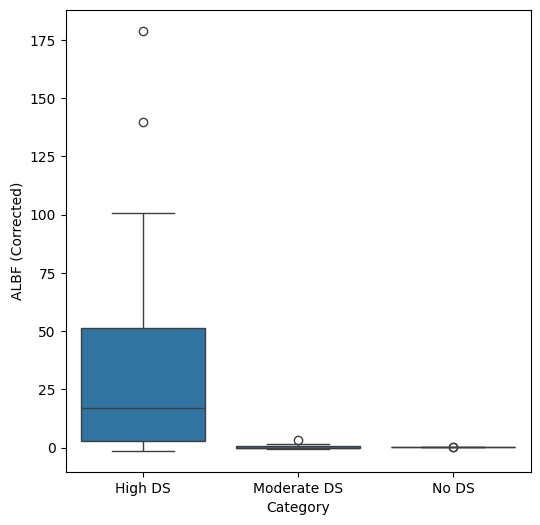

In [175]:
# Set up the matplotlib figure
plt.figure(figsize=(6, 6))
# plot correct ALBF values versus category using df_albf_corrected
sns.boxplot(x="Category", y="ALBF (Corrected)", data=df_albf_corrected)


In [176]:
# sort the dataframe by corrected ALBF vlaues
df_albf_corrected.sort_values("ALBF (Corrected)", ascending=False)

,Junction,ALBF,ALBF (Corrected),Log Pj(H0),Category,Sigmoid
22,23,180.413849,178.913655,-180.413849,High DS,1.000000
1,2,141.324646,139.824452,-141.324646,High DS,1.000000
20,21,101.971626,100.471432,-101.971626,High DS,1.000000
32,33,94.228180,92.727986,-94.228180,High DS,1.000000
4,5,90.178612,88.678418,-90.178612,High DS,1.000000
...,...,...,...,...,...,...
64,65,0.919224,-0.580970,-0.919224,Moderate DS,0.358709
34,35,0.919005,-0.581189,-0.919005,Moderate DS,0.358659
6,7,0.557598,-0.942596,-0.557598,High DS,0.280376
28,29,0.229014,-1.271180,-0.229014,High DS,0.219055


<Axes: >

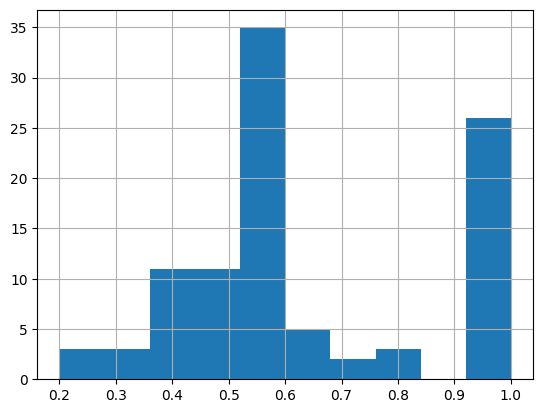

In [177]:
df_albf_corrected.Sigmoid.hist()

In [184]:
from scipy.stats import norm

def plot_gaussian(means, variances):
    """
    Plots Gaussian distributions given lists of means and variances.
    
    Parameters:
        means (list of float): List of mean values for the Gaussians.
        variances (list of float): List of variance values for the Gaussians.
    """
    if len(means) != len(variances):
        raise ValueError("Means and variances lists must have the same length.")
    
    print(means, variances)

    # Compute standard deviations from variances
    std_devs = np.sqrt(variances)
    
    # Dynamically determine the x-range
    x_min = min(means) - 3 * max(std_devs)
    x_max = max(means) + 3 * max(std_devs)

    # Whichever is absolute bigger number set range to be that value on both sides 
    if abs(x_min) > abs(x_max):
        x_max = abs(x_min)
    else:
        x_min = -abs(x_max)

    x = np.linspace(x_min, x_max, 1000)
    
    # Plot Gaussian distributions
    fig, ax = plt.subplots(figsize=(6, 6))
    for mu, sigma in zip(means, std_devs):
        ax.plot(x, norm.pdf(x, mu, sigma))
        # Sample z from the Gaussian distribution
        z = np.random.normal(mu, sigma, 5)
        # Get PSI values from z
        psi_values = inverse_logit(torch.tensor(z))
        print(torch.mean(psi_values))

    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.set_title("Gaussian Distributions")
    plt.show()

[tensor(-0.9808), tensor(0.1947)] [tensor(0.5000), tensor(0.5000)]
tensor(0.3137, dtype=torch.float64)
tensor(0.5975, dtype=torch.float64)


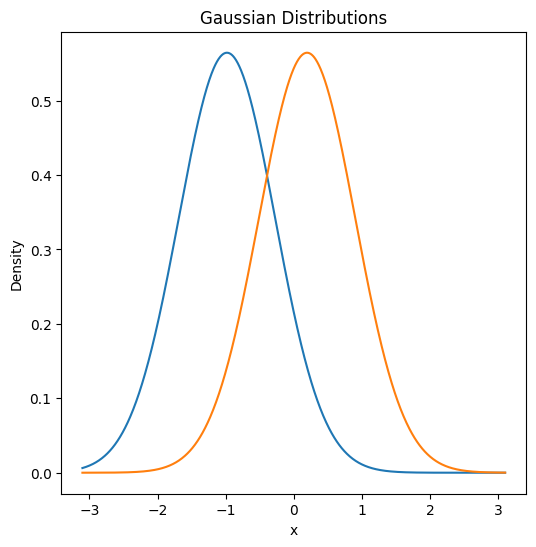

In [190]:
index_junc = 65
plot_gaussian(list(means[index_junc]), list(variances[index_junc]))  # Plots two Gaussian distributions


In [188]:
# sort by ALBF (Corrected) values
df_albf_corrected.sort_values("ALBF (Corrected)", ascending=True)[0:10]

,Junction,ALBF,ALBF (Corrected),Log Pj(H0),Category,Sigmoid
12,13,0.118904,-1.381290,-0.118904,High DS,0.200802
28,29,0.229014,-1.271180,-0.229014,High DS,0.219055
6,7,0.557598,-0.942596,-0.557598,High DS,0.280376
34,35,0.919005,-0.581189,-0.919005,Moderate DS,0.358659
64,65,0.919224,-0.580970,-0.919224,Moderate DS,0.358709
42,43,0.920592,-0.579602,-0.920592,Moderate DS,0.359024
45,46,0.944542,-0.555652,-0.944542,Moderate DS,0.364554
47,48,0.964629,-0.535565,-0.964629,Moderate DS,0.369220
57,58,0.965924,-0.534270,-0.965924,Moderate DS,0.369522
55,56,0.966543,-0.533651,-0.966543,Moderate DS,0.369666
